In [1]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.recommend_model import (
    LinearRecommender,
    RandomForestRecommender,
    CatBoostRecommender,
    NCFRecommender
)

In [2]:
df = pd.read_csv("../data/recommender_training.csv")

# --- split user ---
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# 2) Val 15%, Test 15%
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (82555, 12)
Val  : (17690, 12)
Test : (17691, 12)


In [ ]:
linear = LinearRecommender()
linear.train(train_df)

[LinearRegression] Training finished.
✓ [LinearRegression] Model saved to ../models/linearregression_rec.pkl


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, make_scorer

# ----- Chuẩn bị dữ liệu -----
rf_tmp = RandomForestRecommender()
train_fe = rf_tmp.feature_engineering(train_df)
train_fe = rf_tmp.fit_encoders(train_fe)

X_train = train_fe[rf_tmp.features]
y_train = train_fe["label"]

# ----- Grid Search -----
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "max_features": [0.6, 0.7, 0.8]
}

rmse_scorer = make_scorer(
    lambda y, y_pred: mean_squared_error(y, y_pred, squared=False),
    greater_is_better=False
)

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    scoring=rmse_scorer,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best RF params:", grid.best_params_)
print("Best RF RMSE:", -grid.best_score_)

# ----- Train model cuối -----
best_rf_params = grid.best_params_
print(best_rf_params)

rf = RandomForestRecommender(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    max_features=best_rf_params["max_features"]
)

rf.train(train_df)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF params: {'max_depth': None, 'max_features': 0.8, 'n_estimators': 200}
Best RF RMSE: 0.004314079633429245
{'max_depth': None, 'max_features': 0.8, 'n_estimators': 200}
[RandomForest] Training finished
Params: {'n_estimators': 200, 'max_depth': None, 'max_features': 0.8, 'random_state': 42, 'n_jobs': -1}


[CatBoost] Training finished.


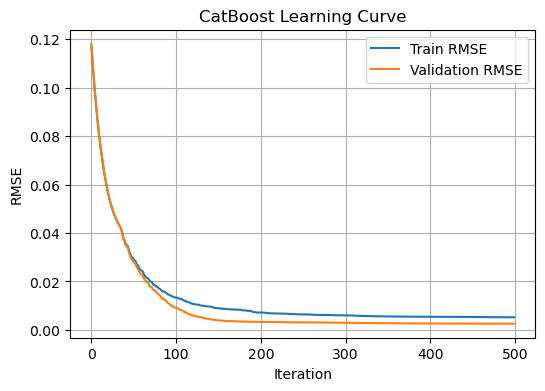

✓ [CatBoost] Model saved to ../models/catboost_rec.pkl


In [ ]:
cat = CatBoostRecommender()
cat.train(train_df, val_df)

train_rmse = cat.evals_result["learn"]["RMSE"]
val_rmse   = cat.evals_result["validation"]["RMSE"]

plt.figure(figsize=(6,4))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import random

search_space = {
    "emb_dim": [16, 32, 64],
    "lr": [1e-4, 5e-4, 1e-3],
    "batch_size": [256, 512],
    "epochs": [20, 30],
    "patience": [3, 5]
}

best_rmse = float("inf")
best_config = None
best_model = None

for i in range(5):   # số lần random thử
    config = {k: random.choice(v) for k, v in search_space.items()}
    print(f"\nTrial {i+1}: {config}")

    model = NCFRecommender(emb_dim=config["emb_dim"])
    model.train(
        train_df=train_df,
        val_df=val_df,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        lr=config["lr"],
        patience=config["patience"]
    )

    val_rmse = np.sqrt(model.val_losses[-1])

    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_config = config
        best_model = model

print("\nBest hyperparameters found by Random Search:")
print(f"Embedding dim : {best_config['emb_dim']}")
print(f"Learning rate : {best_config['lr']}")
print(f"Batch size    : {best_config['batch_size']}")
print(f"Epochs        : {best_config['epochs']}")
print(f"Patience      : {best_config['patience']}")
print(f"➡ Best Val RMSE: {best_rmse:.4f}")



Trial 1: {'emb_dim': 32, 'lr': 0.001, 'batch_size': 512, 'epochs': 30, 'patience': 5}
[NCF] Epoch 1/30 | Train MSE: 0.0409 | Val MSE: 0.0168
[NCF] Epoch 2/30 | Train MSE: 0.0145 | Val MSE: 0.0136
[NCF] Epoch 3/30 | Train MSE: 0.0121 | Val MSE: 0.0121
[NCF] Epoch 4/30 | Train MSE: 0.0109 | Val MSE: 0.0114
[NCF] Epoch 5/30 | Train MSE: 0.0104 | Val MSE: 0.0110
[NCF] Epoch 6/30 | Train MSE: 0.0101 | Val MSE: 0.0109
[NCF] Epoch 7/30 | Train MSE: 0.0098 | Val MSE: 0.0107
[NCF] Epoch 8/30 | Train MSE: 0.0095 | Val MSE: 0.0106
[NCF] Epoch 9/30 | Train MSE: 0.0093 | Val MSE: 0.0106
[NCF] Epoch 10/30 | Train MSE: 0.0091 | Val MSE: 0.0105
[NCF] Epoch 11/30 | Train MSE: 0.0089 | Val MSE: 0.0103
[NCF] Epoch 12/30 | Train MSE: 0.0087 | Val MSE: 0.0102
[NCF] Epoch 13/30 | Train MSE: 0.0085 | Val MSE: 0.0101
[NCF] Epoch 14/30 | Train MSE: 0.0084 | Val MSE: 0.0101
[NCF] Epoch 15/30 | Train MSE: 0.0082 | Val MSE: 0.0101
[NCF] Epoch 16/30 | Train MSE: 0.0081 | Val MSE: 0.0100
[NCF] Epoch 17/30 | Train 

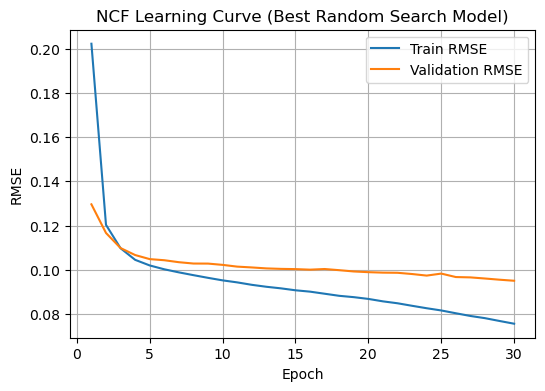

In [7]:
epochs = range(1, len(best_model.train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, np.sqrt(best_model.train_losses), label="Train RMSE")
plt.plot(epochs, np.sqrt(best_model.val_losses), label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NCF Learning Curve (Best Random Search Model)")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
ncf = NCFRecommender(emb_dim=best_config["emb_dim"])
ncf.train(
    train_df=train_df,
    val_df=val_df,
    epochs=best_config["epochs"],
    batch_size=best_config["batch_size"],
    lr=best_config["lr"],
    patience=best_config["patience"]
)

[NCF] Epoch 1/30 | Train MSE: 0.0562 | Val MSE: 0.0182
[NCF] Epoch 2/30 | Train MSE: 0.0157 | Val MSE: 0.0146
[NCF] Epoch 3/30 | Train MSE: 0.0128 | Val MSE: 0.0127
[NCF] Epoch 4/30 | Train MSE: 0.0114 | Val MSE: 0.0118
[NCF] Epoch 5/30 | Train MSE: 0.0106 | Val MSE: 0.0114
[NCF] Epoch 6/30 | Train MSE: 0.0102 | Val MSE: 0.0111
[NCF] Epoch 7/30 | Train MSE: 0.0099 | Val MSE: 0.0109
[NCF] Epoch 8/30 | Train MSE: 0.0096 | Val MSE: 0.0108
[NCF] Epoch 9/30 | Train MSE: 0.0094 | Val MSE: 0.0106
[NCF] Epoch 10/30 | Train MSE: 0.0092 | Val MSE: 0.0105
[NCF] Epoch 11/30 | Train MSE: 0.0090 | Val MSE: 0.0104
[NCF] Epoch 12/30 | Train MSE: 0.0089 | Val MSE: 0.0103
[NCF] Epoch 13/30 | Train MSE: 0.0087 | Val MSE: 0.0102
[NCF] Epoch 14/30 | Train MSE: 0.0085 | Val MSE: 0.0102
[NCF] Epoch 15/30 | Train MSE: 0.0084 | Val MSE: 0.0102
[NCF] Epoch 16/30 | Train MSE: 0.0083 | Val MSE: 0.0102
[NCF] Epoch 17/30 | Train MSE: 0.0082 | Val MSE: 0.0101
[NCF] Epoch 18/30 | Train MSE: 0.0080 | Val MSE: 0.0100
[

In [9]:
def evaluate_regression_model(recommender, df):
    """
    Đánh giá regression thuần (label prediction)
    """
    df = recommender.feature_engineering(df)

    if "CatBoost" in recommender.model_name:
        for col in recommender.cat_features:
            df[col] = df[col].astype(str).fillna("unknown")

        X = df[recommender.features]

    else:
        df = recommender.transform_encoders(df)
        X = df[recommender.features]
        if recommender.scaler:
            X = recommender.scaler.transform(X)

    y = df["label"]

    return recommender.evaluate(X, y)


In [10]:
def build_ground_truth(df, top_n=5):
    return (
        df.sort_values("label", ascending=False)
          .groupby("user_id")
          .head(top_n)
          .groupby("user_id")["poi_id"]
          .apply(set)
          .to_dict()
    )

In [11]:
def precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    return len(set(rec_k) & relevant) / k

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)

In [12]:
def evaluate_recommender(recommender, df_test, poi_df, k=10):
    gt = build_ground_truth(df_test, top_n=k)

    precisions, recalls = [], []
    skipped = 0

    for user_id, relevant_pois in gt.items():

        # --- SKIP cold-start user cho NCF ---
        if recommender.model_name == "NCF":
            if user_id not in recommender.user_encoder.classes_:
                skipped += 1
                continue

        city, user_type, price = user_id.split("_")

        candidate_ids = df_test[df_test["user_id"] == user_id]["poi_id"]
        candidate_pois = poi_df[poi_df["poi_id"].isin(candidate_ids)]

        if candidate_pois.empty:
            continue

        recs = recommender.recommend(
            df_raw=candidate_pois,
            city=city,
            user_type=user_type,
            user_price=int(price),
            top_k=k
        )

        if recs.empty:
            continue

        recommended_pois = recs["poi_id"].tolist()

        precisions.append(len(set(recommended_pois) & relevant_pois) / k)
        recalls.append(len(set(recommended_pois) & relevant_pois) / max(1, len(relevant_pois)))

    return {
        f"Precision@{k}": np.mean(precisions) if precisions else 0.0,
        f"Recall@{k}": np.mean(recalls) if recalls else 0.0
    }

In [13]:
poi_df = pd.read_csv("../data/POI.csv")

print("=== REGRESSION METRICS ===")
print("Linear:", evaluate_regression_model(linear, test_df))
print("RandomForest:", evaluate_regression_model(rf, test_df))
print("CatBoost:", evaluate_regression_model(cat, test_df))


print("=== RANKING METRICS ===")
print("Linear:", evaluate_recommender(linear, test_df, poi_df))
print("RandomForest:", evaluate_recommender(rf, test_df, poi_df))
print("CatBoost:", evaluate_recommender(cat, test_df, poi_df))
print("NCF:", evaluate_recommender(ncf, test_df, poi_df))


=== REGRESSION METRICS ===
Linear: {'MAE': 0.06382717198723678, 'RMSE': 0.08462653421226289, 'R2': 0.5296186527262834}
RandomForest: {'MAE': 0.0003336685320240019, 'RMSE': 0.00303179120221764, 'R2': 0.9993962800073777}
CatBoost: {'MAE': 0.000920014146328136, 'RMSE': 0.002415732384940156, 'R2': 0.999616703702467}
=== RANKING METRICS ===
Linear: {'Precision@10': 0.4373844121532365, 'Recall@10': 0.739101717305152}
RandomForest: {'Precision@10': 0.6685601056803171, 'Recall@10': 0.9702774108322325}
CatBoost: {'Precision@10': 0.6686922060766183, 'Recall@10': 0.9704095112285337}
NCF: {'Precision@10': 0.37974322396576315, 'Recall@10': 0.6336661911554922}


In [14]:
# ===== FINAL TRAIN DATA (train + val) =====
full_train_df = pd.concat([train_df, val_df], ignore_index=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Final Train (train+val):", full_train_df.shape)

final_cat = CatBoostRecommender()

# Train trên toàn bộ train + val
final_cat.train(full_train_df)

# Save model FINAL
final_cat.save("../models/catboost_rec_final.pkl")

Train: (82555, 12)
Val  : (17690, 12)
Final Train (train+val): (100245, 12)
[CatBoost] Training finished.
✓ [CatBoost] Model saved to ../models/catboost_rec_final.pkl


In [21]:
top_poi = final_cat.recommend(
    df_raw=poi_df,
    city="da lat",
    user_type="restaurant",
    user_price=0,
    top_k=50
)

print(top_poi)

              poi_id                                               name  \
235  restaurant01795                             MI-An restaurant Dalat   
228  restaurant01788                                       Vegan Noodle   
238  restaurant01798  Lam An (Mì Quảng, Cơm Gà & Món Cuốn) - Vietnam...   
175  restaurant00992                           Quán Của Thời Thanh Xuân   
218  restaurant01778                                     VLC Restaurant   
208  restaurant01768                                Com Linh Restaurant   
204  restaurant01764                    Tiệm ăn Đà Lạt Phố - Restaurant   
236  restaurant01796                                      Hawaiian Poke   
219  restaurant01779                         Ty Crêpe French Restaurant   
205  restaurant01765                         Trang's Cookery Restaurant   
211  restaurant01771                                  KALACÁ Restaurant   
213  restaurant01773                      MiMi Sushi & Pizza Restaurant   
229  restaurant01789     